# Project A3 “Motor imagery classification from EEG for brain computer interface”

## Introduction

Motor Imagery (MI) refers to the mental simulation of movement without any actual physical execution. EEG-based MI classification is a core component of Brain–Computer Interface (BCI) systems, enabling direct communication between the brain and external devices by decoding neural activity patterns associated with imagined movements.

In this notebook, we explore different end-to-end pipelines for **EEG Motor Imagery classification using Python**. The workflow includes EEG data loading, preprocessing, feature extraction, and supervised machine learning–based classification. 

In [1]:
import importlib
import scipy.io
import utils.utils as u 
import utils.preprocessing as p 
import utils.models as m 
import numpy as np
import mne
import polars as pl
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
import random
import matplotlib.pyplot as plt
from mne.decoding import CSP

# Reload modules to reflect recent changes:
importlib.reload(u)
importlib.reload(p)
importlib.reload(m)

SEED=42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

## Data loading
We will start by loading the dataset. This dataset is divided in 3 different experiments:

- CLA -  Left and Right hand movement, or passive (3 classes)
- HaLT - Left and Right hand/leg, tongue and passive (6 classes)
- 5F -  Five fingers movement (more challenging) (5 classes)

The files are coming from MatLab, which makes them have some additional metadata that we will have to get rid of. Additionally, the file names give us some information about the patients. Since we are experimenting on the eeg signals alone, we will not use this information, even if it could potentially boost our results.

The dataset contains EEG recordings stored as a two-dimensional MATLAB array of size nS × 22, where each column represents a time series of voltage measurements from a single EEG channel. The recording includes 19 EEG leads arranged according to the international 10–20 system, two reference (ground) electrodes (A1 and A2), and one synchronization channel (X3 or X5). The synchronization channel does not contain physiological data and should be used solely to verify temporal alignment between the EEG data and the corresponding marker information.

Reference paper of the dataset: [Kaya18] Kaya, M., et al. A large electroencephalographic motor imagery
dataset for electroencephalographic brain computer interfaces, in Scientific
data, vol. 5, no. 1, pp. 1–16, 2018. 

https://www.researchgate.net/publication/328328921_A_large_electroencephalographic_motor_imagery_dataset_for_electroencephalographic_brain_computer_interfaces

All decisions taken in this notebook are based on different papers. The main paper that we follow as a general guideline is the following one:

[Altaheri23] H. Altaheri et al., Deep learning techniques for classification of
electroencephalogram (EEG) motor imagery (MI) signals: A review, Neural
Computing and Applications, vol. 35, no. 20, pp. 14681–14722, 2023

https://www.researchgate.net/publication/353327259_Deep_Learning_Techniques_for_Classification_of_Electroencephalogram_EEG_Motor_Imagery_MI_Signals_A_Review

This paper will be the backbone of our decisions regarding preprocessing, feature extraction and model selection. During the process we will refer to this paper often as [Altaheri23] and also refer to other papers that tackle specific problems.

 _NOTE: In the notebook some of the functions, that we though to be redundant are coming from additional python files, intending to make the code clearer and easier to follow. You can check this functions in the complementary python files if needed_

In [2]:
# Get the file names from directory of the files of the experiment
files=u.get_file_names("../data", experiment="CLA")
print(files)

['../data/CLA-SubjectA-160108-3St-LRHand.mat', '../data/CLA-SubjectB-151019-3St-LRHand.mat', '../data/CLA-SubjectB-151020-3St-LRHand.mat', '../data/CLA-SubjectB-151215-3St-LRHand.mat', '../data/CLA-SubjectC-151126-3St-LRHand.mat', '../data/CLA-SubjectC-151216-3St-LRHand.mat', '../data/CLA-SubjectC-151223-3St-LRHand.mat', '../data/CLA-SubjectD-151125-3St-LRHand.mat', '../data/CLA-SubjectE-151225-3St-LRHand.mat', '../data/CLA-SubjectE-160119-3St-LRHand.mat', '../data/CLA-SubjectE-160122-3St-LRHand.mat', '../data/CLA-SubjectF-150916-3St-LRHand.mat', '../data/CLA-SubjectF-150917-3St-LRHand.mat', '../data/CLA-SubjectF-150928-3St-LRHand.mat', '../data/CLA-SubjectJ-170504-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170508-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170510-3St-LRHand-Inter.mat']


In [3]:
FILE=files[0] #TO DO: Choose one file for now, later we will loop over all files
mat_data = scipy.io.loadmat(FILE)

# The file includes metadata coming from python that we don't need.
# We will focus on the 'o' key which contains the EEG data and information about the experiment.

data = mat_data['o'][0, 0]       
print(f"Data keys include:{data.dtype.names}.\n") 
sfreq = int(data['sampFreq'][0, 0]) if data['sampFreq'].size > 0 else 200
eeg_data = data['data'].T  # Shape: (n_channels, n_samples)
channel_names = [
    str(ch[0]).strip("[]' ")
    for ch in data["chnames"]
]
info = mne.create_info(
            ch_names=channel_names,
            sfreq=sfreq,
            ch_types='eeg'
        )
        
info.set_channel_types({"X5": "misc"}) # Set 'X5' as misc type to avoid errors
montage = mne.channels.make_standard_montage('standard_1020') # Set standard 10-20 montage
info.set_montage(montage)
raw = mne.io.RawArray(eeg_data, info)
print(raw.info)

Data keys include:('id', 'tag', 'sampFreq', 'nS', 'marker', 'data', 'chnames', 'binsuV').

Creating RawArray with float64 data, n_channels=22, n_times=671600
    Range : 0 ... 671599 =      0.000 ...  3357.995 secs
Ready.
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, A1, A2, F7, F8, T3, ...
 chs: 21 EEG, 1 misc
 custom_ref_applied: False
 dig: 24 items (3 Cardinal, 21 EEG)
 highpass: 0.0 Hz
 lowpass: 100.0 Hz
 meas_date: unspecified
 nchan: 22
 projs: []
 sfreq: 200.0 Hz
>


C:\Users\josub\AppData\Local\Temp\ipykernel_25188\2525920758.py:21: RuntimeWarning: The unit for channel(s) X5 has changed from V to NA.
  info.set_channel_types({"X5": "misc"}) # Set 'X5' as misc type to avoid errors


# PREPROCESSING

First of all, as the dataset paper suggests, let's check if the syncronization is correct. First let's check if all the marker arrays are of the same length. As we will see, they are close but not perfect.

In [30]:
labels = np.array(data['marker'])
import numpy as np
from itertools import groupby
grouped_data = []
for k, g in groupby(labels):
    series_length = len(list(g))
    grouped_data.append((k, series_length))
for marker, length in grouped_data[:10]:
    if marker != 0:  # Only print non-zero markers
        print(f"Marker {marker}: Length {length}")
non_zero_lengths = [length for k, length in grouped_data if k != 0]
if non_zero_lengths:
    print(f"\nMinimum length of a non-zero marker series: {min(non_zero_lengths)}")
    


Marker [3]: Length 203
Marker [3]: Length 203
Marker [1]: Length 203
Marker [1]: Length 204
Marker [2]: Length 203

Minimum length of a non-zero marker series: 202


As seen the markers are not of the same length, which is suspicious. Let's check if the syncronization is correct.

Sync channel data (first 10 samples): [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
Spike indixes:[1855 1856 1857 1858 1859 1860 1861 1862 3060 3061]
Compute gaps:[   1    1    1    1    1    1    1 1198    1    1]
Indices in gaps:[ 7 18 42 72 73 74 76 78 81 84]
Spike onsets in the plotted window: [100399 101084 101634]


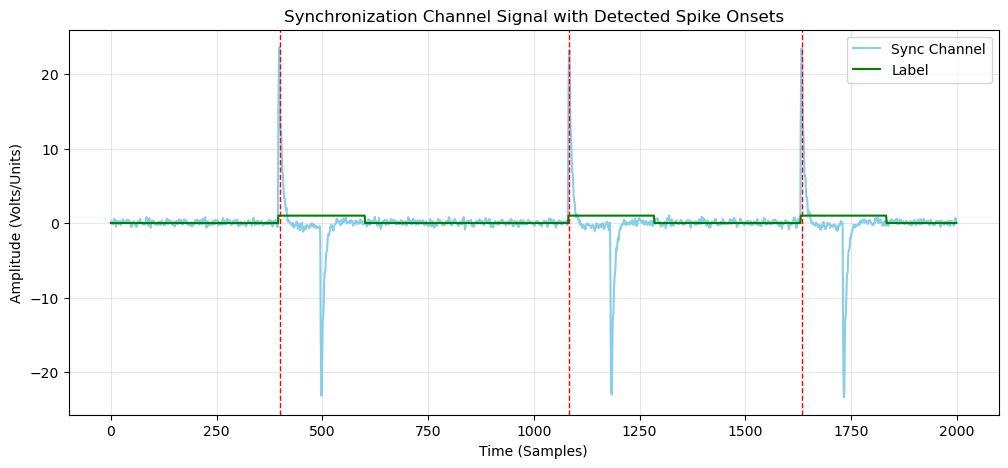

In [31]:
COLOR_MAP = {
    0: 'gray',    # Baseline/Rest
    1: 'blue',    # Mental Imagery 1
    2: 'red',     # Mental Imagery 2
    3: 'green',   # Mental Imagery 3 
}
THRESHOLD=20
sync_data = raw.get_data(picks='X5').flatten()
print(f"Sync channel data (first 10 samples): {sync_data[:10]}")
spikes=np.where(sync_data> 20)[0]
print(f"Spike indixes:{spikes[:10]}")
gaps = np.diff(spikes)
print(f"Compute gaps:{gaps[:10]}")

indices_in_gaps = np.where(gaps > 2)[0]
print(f"Indices in gaps:{indices_in_gaps[:10]}")
first_spike= spikes[0]
subsequent_spikes = spikes[indices_in_gaps]
final_spike_onsets = np.concatenate([[first_spike], subsequent_spikes])


START_OFFSET = 100000
WINDOW= 2000
plt.figure(figsize=(12, 5))
plt.plot(range(WINDOW), sync_data[START_OFFSET: START_OFFSET+WINDOW], label='Sync Channel', color='skyblue')
plt.plot(range(WINDOW), data["marker"][START_OFFSET: START_OFFSET+WINDOW], label='Label', color='green')

spikes_plot = final_spike_onsets[(final_spike_onsets >= START_OFFSET) & (final_spike_onsets < START_OFFSET + WINDOW)]
print(f"Spike onsets in the plotted window: {spikes_plot}")
for onset in spikes_plot:
    # Only label the first vertical line for a clean legend
    plt.axvline(x=onset-START_OFFSET, color='red', linestyle='--', linewidth=1)


plt.title('Synchronization Channel Signal with Detected Spike Onsets')
plt.xlabel('Time (Samples)')
plt.ylabel('Amplitude (Volts/Units)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



The syncronization seems to be right we just need to change the length of the windows to be consistent. We will do this later, since we will use a mne object called Epochs which will help us to cut our eeg data in even slices to classify. For this we will need to create an events object with the labels and the first marker index of each event. We will filter out the 0 label parts in this step too.

In [32]:
markers_diff = np.diff(data["marker"].squeeze())
all_transition_indices = np.where(markers_diff != 0)[0] + 1
all_values = data["marker"].squeeze()[all_transition_indices]
valid_mask = all_values != 0 #WE ARE TAKING ONLY NON-ZERO EVENTS
event_samples_filtered = all_transition_indices[valid_mask]
event_values_filtered = all_values[valid_mask]

# 4. Reconstruct the events array
event_count = len(event_samples_filtered)
events = np.column_stack([
    event_samples_filtered, 
    np.zeros(event_count, dtype=int), 
    event_values_filtered
]).astype(int)

print(f"Total Meaningful Events Found: {event_count}")
print(f"Unique Labels Found: {np.unique(event_values_filtered)}")
print(f"Events (first 10):\n{events[:10]}")


Total Meaningful Events Found: 960
Unique Labels Found: [1 2 3]
Events (first 10):
[[37272     0     3]
 [37783     0     3]
 [38370     0     1]
 [39022     0     1]
 [39555     0     2]
 [40111     0     1]
 [40695     0     2]
 [41278     0     2]
 [41815     0     1]
 [42342     0     1]]


Quoting [Altaheri23]: "Pre-processing is generally performed in three main 
steps: channel selection, signal frequency filtering, and 
artifact removal."

One big candidate here is using the PREP pipeline, which was created as standarized preprocessing for EEG:

[ N. Bigdely-Shamlo, T. Mullen, C. Kothe, K. M. Su, and K. A. Robbins, \The prep pipeline: Standardized preprocessing for large-scale eeg analysis," Frontiers in Neuroinformatics, vol. 9, no. 16, 2015.]

https://www.frontiersin.org/journals/neuroinformatics/articles/10.3389/fninf.2015.00016/full

However our dataset does not seem a good candidate. Let's see why, going through the steps of the PREP pipeline
1. Line Noise Removal (Unwanted electrical interference from the power supply in the environment) 
 However or data has been already notched at 50Hz, so we can skip this step.  (From the paper: "These are the hardware filters and therefore part of all the published records. Additionally, a 50 Hz notch filter is present in the EEG-1200 hardware to reduce electrical grid interference.")\n
 A high-pass cutoff has been passed.

2. Robust Referencing 
 Robust referencing is essentialy a normalization, between the channels considered not bad. However, we will not do robust refencing. In the dataset paper technical validation section, which we closelly look since it is a similar experiment in the same data as ours, they followed the following pipeline and methodology:

[Mishchenko] Mishchenko, Y., Kaya, M., Ozbay, E. & Yanar, H. Developing a 3- to 6-state EEG-based brain-computer interface for a virtual
robotic manipulator control. IEEE Trans Biomed Eng. Epub ahead of print, https://doi.org/10.1109/TBME.2018.2865941
(2018).

https://www.researchgate.net/publication/319878377_Developing_a_3-_to_6-state_EEG-based_brain-computer_interface_for_a_robotic_manipulator_control

In this paper, after experimenting with several referencing systems, Laplace refencing is suggested as having the overall best performance. 

3. Bad Channel Interpolation
THIS CAN BE DONE

(4. Rereferencing or undo interpolation)


In [34]:
eeg_channels = [ch for ch in channel_names if ch not in ['X5','X3']]
# --- High-pass cutoff ---
raw.filter(l_freq=1.0, h_freq=None)
# --- Laplace Reference (Surface Laplacian) ---
# In MNE, this is often done by calculating the Surface Laplacian.
raw_laplace = mne.preprocessing.compute_current_source_density(raw.copy().pick("eeg"))

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 661 samples (3.305 s)

Fitted sphere radius:         95.6 mm
Origin head coordinates:      -0.9 15.8 45.4 mm
Origin device coordinates:    -0.9 15.8 45.4 mm


Here we create the Epochs object (splitting the data in equivalent length slices), the tmin and tmax have been chosen as [Mishchenko] and the technical validation suggest it as the best windowing: "As described in Results, the
decoding data frame choice of t1= 0sec and t2= 0.85sec
was found to offer the best overall performance for all subjects
and all mental imageries."

In [ ]:
epochs_laplace = mne.Epochs(
    raw=raw_laplace,
    events=events,
    tmin=0,
    tmax=0.85,
    baseline=None,
    preload=True
)

Not setting metadata
960 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 960 events and 171 original time points ...
0 bad epochs dropped


In [ ]:
#Transform the epochs to numpy arrays
X = epochs_laplace.get_data()  # (n_epochs, n_channels, n_times)
y= epochs_laplace.events[:, 2]

Now let's do data augmentation. Data augmentation helps address overfitting by artificially increasing the diversity of the training data while preserving the underlying physiological characteristics of the signals. By introducing controlled variations models become more robust to inter-trial and inter-subject variability, ultimately improving classification performance and stability in EEG motor imagery tasks.

For data augmentation we will refer to one of the papers suggested by the teachers in the project presentation:

[Zhang21] C. Zhang, Y.-K. Kim, and A. Eskandarian, EEG-inception: an accurate and robust end-to-end 
neural network for EEG-based motor imagery classification, Journal of Neural Engineering, vol. 18, no. 
4, p. 046014, 2021.

https://www.researchgate.net/publication/348802845_EEG-Inception_An_Accurate_and_Robust_End-to-End_Neural_Network_for_EEG-based_Motor_Imagery_Classification

They used an 8th-order Butterworth high-pass filter with a cut-off frequency of 100 Hz (in our case 90Hz due to our low frequency rate) to first extract noise candidates. The extracted noise components are then subtracted from the original EEG signals and another random noise candidate is  added to the signal. This way by substracting and adding different noise, we can generate up to n-1 times more data. In our case we will just increasy times 3.

In [ ]:
import numpy as np
from scipy.signal import butter, filtfilt

def augment_eeg_data(X, y, multiplier=3):
    n_trials, n_chans, n_samples = X.shape
    
    # 1. Extract Noise (>90Hz) from all trials (We can't do 100Hz because original data is sampled at 200Hz)
    b, a = butter(8, 90, btype='high', fs=sfreq)
    noise_candidates = filtfilt(b, a, X, axis=-1)
    
    # 2. Extract Clean Signals (<90Hz)
    clean_signals = X - noise_candidates
    
    X_aug_list = [X] # Start with original data
    y_aug_list = [y]
    
    for _ in range(multiplier - 1):
        # Create a randomized version of the dataset
        X_new = np.zeros_like(X)
        for i in range(n_trials):
            # Pick a random trial k to get noise from
            k = np.random.randint(0, n_trials)
            # S_aug = Clean_i + Noise_k
            X_new[i] = clean_signals[i] + noise_candidates[k]
        
        X_aug_list.append(X_new)
        y_aug_list.append(y)
        
    return np.concatenate(X_aug_list, axis=0), np.concatenate(y_aug_list, axis=0)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

unique_labels = np.unique(y)
N = len(unique_labels)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)
X_train, y_train = augment_eeg_data(X_train, y_train, multiplier=3) #WE AUGMENT ONLY THE TRAINING SET

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y
)

# Convert to dict {class_index: weight}
class_weights = dict(enumerate(class_weights_array))
print(class_weights)

print(X_train.shape, X_val.shape, X_test.shape)


{0: 1.0596026490066226, 1: 0.9411764705882353, 2: 1.0062893081761006}
(2016, 21, 171) (144, 21, 171) (144, 21, 171)


# FEATURE EXTRACTION 
As summarized in [Altaheri23], EEG signals can be approched in 4 different ways:

1. Extracting features
2. Using spectral images
3. Directly using the raw preprocessed data
4. Using topological maps

For **1. Extracting features** we will follow the two main suggested approaches in [Altaheri23]: "Luo et al. utilized FBCSP to extract spatial-frequency sequential time slices from MI-EEG signals and classified them using long short-term memory (LSTM) and gated 
recurrent unit (GRU) models. The proposed method achieved good results for both recurrent models. In, the authors also used the FBCSP approach to extract spatial features from MI data and fed them into a CNN model as a 2D matrix."

Our approach is not exactly the same to the one found on the papers cited but it is inspired by them. It will be explained why and how later. The two papers are:

T. Luo and F. Chao, “Exploring spatial-frequency-sequential 
relationships for motor imagery classification with recurrent neural 
network,” BMC Bioinformatics, vol. 19, no. 1, p. 344, 2018. 

https://www.researchgate.net/publication/327967384_Exploring_spatial-frequency-sequential_relationships_for_motor_imagery_classification_with_recurrent_neural_network

B. E. Olivas-Padilla and M. I. Chacon-Murguia, “Classification of 
multiple motor imagery using deep convolutional neural networks 
and spatial filters,” Appl. Soft Comput., vol. 75, pp. 461–472, 2019. 

https://www.sciencedirect.com/science/article/pii/S156849461830663X?via%3Dihub

For **3. Directly using the raw preprocessed data** we will follow the two papers suggested by the teachers in the in the project presentation: the already referenced [Zhang21] and 

[Lawhern18] V. J. Lawhern, A. J. Solon, N. R. Waytowich, S. M. Gordon, C. P. Hung, and B. J. Lance, 
EEGNet: a compact convolutional neural network for EEG-based brain–computer interfaces, Journal of 
neural engineering, vol. 15, no. 5, p. 056013, 2018.

https://www.researchgate.net/publication/310953136_EEGNet_a_compact_convolutional_neural_network_for_EEG-based_brain-computer_interfaces

TODO: 2 or 4 or both or something else

In [ ]:
from joblib import Parallel, delayed
freq_bands = [[4, 8], [8, 12], [12, 16], [16, 20], [20, 24], [24, 28], [28, 32], [32,36], [36,40]]
all_sequences = []

# 1. Initialize storage
trained_csp_bank = []
train_seq, val_seq, test_seq = [], [], []

def extract_windows(data, n_steps=10):
    n_samples = data.shape[-1]
    win_len = int(n_samples * 0.5) 
    start_indices = np.linspace(0, n_samples - win_len, n_steps).astype(int)
    
    sections = []
    for start in start_indices:
        sections.append(data[..., start:start+win_len])
    return sections

def process_band_to_matrix(low, high, X_train, y_train, X_val, X_test, sfreq):
    # Filter
    xt_b = mne.filter.filter_data(X_train, sfreq, low, high, method='iir', verbose=False)
    xv_b = mne.filter.filter_data(X_val, sfreq, low, high, method='iir', verbose=False)
    xte_b = mne.filter.filter_data(X_test, sfreq, low, high, method='iir', verbose=False)

    csp = CSP(n_components=4, reg='ledoit_wolf', log=True)
    csp.fit(xt_b, y_train)
    W = csp.filters_ 

    def get_matrices(dataset):
        cnn_mats = []
        rnn_mats = []
        
        for trial in dataset:
            # Generate CNN windows (T=3)
            sec_cnn = extract_windows(trial, n_steps=3)
            # Generate RNN windows (T=10) - SWC Strategy
            sec_rnn = extract_windows(trial, n_steps=15)
            
            # Helper to calculate log-var for a list of sections
            def calc_logvar(sections):
                cols = []
                for sec in sections:
                    proj = np.dot(W, sec)
                    cols.append(np.log(np.var(proj, axis=1)))
                return np.stack(cols, axis=1) # Shape: (Components, T)

            cnn_mats.append(calc_logvar(sec_cnn))
            rnn_mats.append(calc_logvar(sec_rnn))
            
        return np.array(cnn_mats), np.array(rnn_mats)

    train_cnn, train_rnn = get_matrices(xt_b)
    val_cnn, val_rnn     = get_matrices(xv_b)
    test_cnn, test_rnn   = get_matrices(xte_b)

    return (train_cnn, val_cnn, test_cnn), (train_rnn, val_rnn, test_rnn)

# --- Parallel Execution ---
results = Parallel(n_jobs=-1)(delayed(process_band_to_matrix)(l, h, X_train, y_train, X_val, X_test, sfreq) 
                              for l, h in freq_bands)
# Extract CNN data: index r[0] contains (train, val, test)
X_train_cnn = np.concatenate([r[0][0] for r in results], axis=1) # (Trials, 36, 3)
X_val_cnn   = np.concatenate([r[0][1] for r in results], axis=1)
X_test_cnn  = np.concatenate([r[0][2] for r in results], axis=1)

# Extract RNN data: index r[1] contains (train, val, test)
X_train_rnn = np.concatenate([r[1][0] for r in results], axis=1) # (Trials, 36, 15)
X_val_rnn   = np.concatenate([r[1][1] for r in results], axis=1)
X_test_rnn  = np.concatenate([r[1][2] for r in results], axis=1)

# Transpose RNN to (Trials, Time, Features) for LSTM/GRU
X_train_rnn = np.transpose(X_train_rnn, (0, 2, 1)) # (Trials, 15, 36)
X_val_rnn   = np.transpose(X_val_rnn, (0, 2, 1))
X_test_rnn  = np.transpose(X_test_rnn, (0, 2, 1))

print(f"CNN Shape: {X_train_cnn.shape}")
print(f"RNN Shape: {X_train_rnn.shape}")

CNN Shape: (2016, 189, 3)
RNN Shape: (2016, 15, 189)


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

n_train_cnn, height_cnn, width_cnn = X_train_cnn.shape
n_val_cnn = X_val_cnn.shape[0]
n_test_cnn = X_test_cnn.shape[0]

scaler_cnn = StandardScaler()

X_train_cnn_flat = X_train_cnn.reshape(n_train_cnn, -1)
X_train_cnn_scaled = scaler_cnn.fit_transform(X_train_cnn_flat)
X_val_cnn_flat = X_val_cnn.reshape(n_val_cnn, -1)
X_val_cnn_scaled = scaler_cnn.transform(X_val_cnn_flat)
X_test_cnn_flat = X_test_cnn.reshape(n_test_cnn, -1)
X_test_cnn_scaled = scaler_cnn.transform(X_test_cnn_flat)

n_train_rnn, n_steps_rnn, n_features_rnn = X_train_rnn.shape
n_val_rnn = X_val_rnn.shape[0]
n_test_rnn = X_test_rnn.shape[0]

scaler_rnn = StandardScaler()

X_train_rnn_flat = X_train_rnn.reshape(-1, n_features_rnn)
X_train_rnn_scaled = scaler_rnn.fit_transform(X_train_rnn_flat)
X_val_rnn_flat = X_val_rnn.reshape(-1, n_features_rnn)
X_val_rnn_scaled = scaler_rnn.transform(X_val_rnn_flat)
X_test_rnn_flat = X_test_rnn.reshape(-1, n_features_rnn)
X_test_rnn_scaled = scaler_rnn.transform(X_test_rnn_flat)

In [ ]:
times = epochs_laplace.times
n_epochs, n_channels, n_times = X.shape
C = X.shape[1]
T = X.shape[2]
print(f"C: {C}, T: {T}, N: {N}")
print("#####################################################\n")


X_train = X_train[:, :, :, np.newaxis] 
X_test = X_test[:, :, :, np.newaxis]   
X_val = X_val[:, :, :, np.newaxis]  

X_train_features_cnn = X_train_cnn_scaled.reshape(n_train_cnn, height_cnn, width_cnn, 1)
X_val_features_cnn   = X_val_cnn_scaled.reshape(n_val_cnn, height_cnn, width_cnn, 1)
X_test_features_cnn  = X_test_cnn_scaled.reshape(n_test_cnn, height_cnn, width_cnn, 1)


X_train_features_rnn = X_train_rnn_scaled.reshape(n_train_rnn, n_steps_rnn, n_features_rnn)
X_val_features_rnn   = X_val_rnn_scaled.reshape(n_val_rnn, n_steps_rnn, n_features_rnn)
X_test_features_rnn   = X_test_rnn_scaled.reshape(n_test_rnn, n_steps_rnn, n_features_rnn)

label_map = {old: new for new, old in enumerate(unique_labels)}
print("Label map:", label_map)
y_train = np.array([label_map[int(l)] for l in y_train])
y_test = np.array([label_map[int(l)] for l in y_test])
y_val = np.array([label_map[int(l)] for l in y_val])
y_train = to_categorical(y_train, num_classes=N)
y_test = to_categorical(y_test, num_classes=N)
y_val = to_categorical(y_val, num_classes=N)

print("\n")
print("#####################################################\n")
print(f"X train shape: {X_train.shape}, X_train_features shape: {X_train_features_cnn.shape}, y train shape: {y_train.shape}")
print(f"X test shape: {X_test.shape}, X_test_features shape: {X_test_features_cnn.shape}, y test shape: {y_test.shape}")
print(f"X val shape: {X_val.shape}, X_val_features shape: {X_val_features_cnn.shape}, y val shape: {y_val.shape}")

C: 21, T: 171, N: 3
#####################################################

Label map: {1: 0, 2: 1, 3: 2}


#####################################################

X train shape: (2016, 21, 171, 1), X_train_features shape: (2016, 189, 3, 1), y train shape: (2016, 3)
X test shape: (144, 21, 171, 1), X_test_features shape: (144, 189, 3, 1), y test shape: (144, 3)
X val shape: (144, 21, 171, 1), X_val_features shape: (144, 189, 3, 1), y val shape: (144, 3)


In [ ]:
import tensorflow as tf
epsilon = 1e-7 

def f1_score_metric(y_true, y_pred):
        
    # Calculate True Positives: (y_true * y_pred) clipped to [0, 1] and summed
    true_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true * y_pred, 0, 1)))
    
    # Calculate Possible Positives (Actual Positives): Sum of true labels
    possible_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true, 0, 1)))
    
    # Calculate Predicted Positives: Sum of predicted labels
    predicted_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_pred, 0, 1)))

    # 2. Calculate Precision and Recall
    precision = true_positives / (predicted_positives + epsilon)
    recall = true_positives / (possible_positives + epsilon)

    # 3. Calculate F1-Score (Harmonic Mean)
    f1_val = 2 * (precision * recall) / (precision + recall + epsilon)
    
    return f1_val

In [ ]:
cnn=m.Simple_CNN(nb_classes=N, input_shape=(X_train_features_cnn.shape[1], X_train_features_cnn.shape[2], 1))
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
cnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 189, 3, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 189, 3, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 189, 3, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 94, 3, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 94, 3, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 94, 3, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 47, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       577,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 596,995 (2.28 MB)

 Trainable params: 596,803 (2.28 MB)

 Non-trainable params: 192 (768.00 B)

In [18]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_cnn.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

history = cnn.fit(
    X_train_features_cnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_features_cnn, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_pred = cnn.predict(X_test_features_cnn)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - f1_score_metric: 0.4570 - loss: 1.8492

63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - f1_score_metric: 0.5392 - loss: 1.3507 - val_f1_score_metric: 0.5630 - val_loss: 0.9081
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - f1_score_metric: 0.7631 - loss: 0.5827

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - f1_score_metric: 0.7906 - loss: 0.5555 - val_f1_score_metric: 0.6014 - val_loss: 0.9293
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - f1_score_metric: 0.8938 - loss: 0.2689

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - f1_score_metric: 0.9066 - loss: 0.2320 - val_f1_score_metric: 0.6733 - val_loss: 1.0180
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - f1_score_metric: 0.9539 - loss: 0.1228 - val_f1_score_metric: 0.6457 - val_loss: 1.2781
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - f1_score_metric: 0.9615 - loss: 0.1092

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - f1_score_metric: 0.9677 - loss: 0.0906 - val_f1_score_metric: 0.6818 - val_loss: 1.3376
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - f1_score_metric: 0.9806 - loss: 0.0674 - val_f1_score_metric: 0.6521 - val_loss: 1.8100
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - f1_score_metric: 0.9802 - loss: 0.0452 - val_f1_score_metric: 0.6604 - val_loss: 1.9022
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - f1_score_metric: 0.9881 - loss: 0.0293 - val_f1_score_metric: 0.6540 - val_loss: 2.3888
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - f1_score_metric: 0.9911 - loss: 0.0312 - val_f1_score_metric: 0.6415 - val_loss: 2.1783
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - f1_score_metric: 0.9933 - loss: 0.0197 - val_f1_score_metric: 0.6393 - val_loss: 2.4109
Epoch 11/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - f1_score_metric: 0.9916 - loss: 0.0291 - val_f1_score_metric: 0.6353 - val_loss: 2.2594
Epoch 12/100
63

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - f1_score_metric: 0.9861 - loss: 0.0575 - val_f1_score_metric: 0.6943 - val_loss: 1.9160
Epoch 13/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - f1_score_metric: 0.9960 - loss: 0.0134 - val_f1_score_metric: 0.6875 - val_loss: 2.6525
Epoch 14/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - f1_score_metric: 0.9935 - loss: 0.0218 - val_f1_score_metric: 0.6834 - val_loss: 2.3010
Epoch 15/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - f1_score_metric: 0.9970 - loss: 0.0130 - val_f1_score_metric: 0.6937 - val_loss: 2.2269
Epoch 16/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - f1_score_metric: 0.9936 - loss: 0.0213 - val_f1_score_metric: 0.6628 - val_loss: 2.1785
Epoch 17/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - f1_score_metric: 0.9965 - loss: 0.0101 - val_f1_score_metric: 0.6875 - val_loss: 2.5740
Epoch 18/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - f1_score_metric: 0.9940 - loss: 0.0132 - val_f1_score_metric: 0.6790 - val_loss: 2.6867
Epoch 19/100

In [19]:
lstm=m.Simple_LSTM(nb_classes=N, input_shape=(X_train_features_rnn.shape[1], X_train_features_rnn.shape[2]))
lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
lstm.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 15, 189)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 189)        │           756 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 15, 64)         │        65,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 15, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 15, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,335 (348.96 KB)

 Trainable params: 88,701 (346.49 KB)

 Non-trainable params: 634 (2.48 KB)

In [20]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_lstm.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

history = lstm.fit(
    X_train_features_rnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_features_rnn, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_pred = lstm.predict(X_test_features_rnn)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - f1_score_metric: 0.3167 - loss: 5.2095

63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - f1_score_metric: 0.3832 - loss: 4.8802 - val_f1_score_metric: 0.1006 - val_loss: 4.3400
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - f1_score_metric: 0.6234 - loss: 3.9764

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - f1_score_metric: 0.6936 - loss: 3.7126 - val_f1_score_metric: 0.6293 - val_loss: 3.5507
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - f1_score_metric: 0.8760 - loss: 2.9413

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - f1_score_metric: 0.9061 - loss: 2.7408 - val_f1_score_metric: 0.6426 - val_loss: 3.1069
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - f1_score_metric: 0.9602 - loss: 2.2469

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - f1_score_metric: 0.9673 - loss: 2.1170 - val_f1_score_metric: 0.6581 - val_loss: 2.9740
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - f1_score_metric: 0.9838 - loss: 1.6766 - val_f1_score_metric: 0.6437 - val_loss: 2.8332
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - f1_score_metric: 0.9861 - loss: 1.3470 - val_f1_score_metric: 0.6207 - val_loss: 2.7187
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - f1_score_metric: 0.9858 - loss: 1.1168 - val_f1_score_metric: 0.6314 - val_loss: 2.6713
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - f1_score_metric: 0.9709 - loss: 1.0183 - val_f1_score_metric: 0.6105 - val_loss: 2.5155
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - f1_score_metric: 0.9829 - loss: 0.8782 - val_f1_score_metric: 0.6059 - val_loss: 2.3724
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - f1_score_metric: 0.9825 - loss: 0.7603 - val_f1_score_metric: 0.6375 - val_loss: 2.3118
Epoch 11/100
62/6

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - f1_score_metric: 0.9930 - loss: 0.6443 - val_f1_score_metric: 0.6625 - val_loss: 2.2834
Epoch 12/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - f1_score_metric: 0.9938 - loss: 0.5653 - val_f1_score_metric: 0.6184 - val_loss: 2.4099
Epoch 13/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - f1_score_metric: 0.9928 - loss: 0.5028 - val_f1_score_metric: 0.6500 - val_loss: 2.0392
Epoch 14/100
62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - f1_score_metric: 0.9917 - loss: 0.4734

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - f1_score_metric: 0.9821 - loss: 0.4925 - val_f1_score_metric: 0.6689 - val_loss: 2.0454
Epoch 15/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - f1_score_metric: 0.9707 - loss: 0.5115 - val_f1_score_metric: 0.6309 - val_loss: 1.9331
Epoch 16/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - f1_score_metric: 0.9911 - loss: 0.4317 - val_f1_score_metric: 0.6522 - val_loss: 1.9193
Epoch 17/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - f1_score_metric: 0.9930 - loss: 0.3795 - val_f1_score_metric: 0.6625 - val_loss: 2.0325
Epoch 18/100
62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - f1_score_metric: 0.9929 - loss: 0.3560

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - f1_score_metric: 0.9943 - loss: 0.3399 - val_f1_score_metric: 0.7000 - val_loss: 1.7736
Epoch 19/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - f1_score_metric: 0.9975 - loss: 0.2998 - val_f1_score_metric: 0.6460 - val_loss: 1.8411
Epoch 20/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - f1_score_metric: 0.9950 - loss: 0.2775 - val_f1_score_metric: 0.6560 - val_loss: 1.8889
Epoch 21/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - f1_score_metric: 0.9911 - loss: 0.2752 - val_f1_score_metric: 0.6522 - val_loss: 1.8656
Epoch 22/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - f1_score_metric: 0.9806 - loss: 0.2882 - val_f1_score_metric: 0.6437 - val_loss: 1.8676
Epoch 23/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - f1_score_metric: 0.9756 - loss: 0.3319 - val_f1_score_metric: 0.6396 - val_loss: 1.7776
Epoch 24/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - f1_score_metric: 0.9928 - loss: 0.2613 - val_f1_score_metric: 0.6123 - val_loss: 2.0796
Epoch 25/100

In [21]:
gru=m.Simple_GRU(nb_classes=N, input_shape=(X_train_features_rnn.shape[1], X_train_features_rnn.shape[2]))
gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
gru.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 15, 189)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 15, 189)        │           756 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │       122,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,215 (516.46 KB)

 Trainable params: 131,581 (513.99 KB)

 Non-trainable params: 634 (2.48 KB)

In [22]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_gru.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

history = gru.fit(
    X_train_features_rnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_features_rnn, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_pred = gru.predict(X_test_features_rnn)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - f1_score_metric: 0.4843 - loss: 4.4657

63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - f1_score_metric: 0.6166 - loss: 3.8067 - val_f1_score_metric: 0.6311 - val_loss: 3.1317
Epoch 2/100
61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - f1_score_metric: 0.8420 - loss: 2.5159

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - f1_score_metric: 0.8590 - loss: 2.3168 - val_f1_score_metric: 0.6603 - val_loss: 2.6575
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - f1_score_metric: 0.9383 - loss: 1.6614 - val_f1_score_metric: 0.6455 - val_loss: 2.5567
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - f1_score_metric: 0.9729 - loss: 1.2919 - val_f1_score_metric: 0.6302 - val_loss: 2.5339
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - f1_score_metric: 0.9714 - loss: 1.0805 - val_f1_score_metric: 0.6327 - val_loss: 2.5565
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - f1_score_metric: 0.9766 - loss: 0.9213 - val_f1_score_metric: 0.6334 - val_loss: 2.5188
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - f1_score_metric: 0.9871 - loss: 0.7612 - val_f1_score_metric: 0.6036 - val_loss: 2.5325
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - f1_score_metric: 0.9844 - loss: 0.6519 - val_f1_score_metric: 0.6375 - val_loss: 2.4738
Epoch 9/100
63/63 

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - f1_score_metric: 0.9846 - loss: 0.3066 - val_f1_score_metric: 0.6646 - val_loss: 2.0935
Epoch 15/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - f1_score_metric: 0.9910 - loss: 0.2635 - val_f1_score_metric: 0.6523 - val_loss: 2.0364
Epoch 16/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - f1_score_metric: 0.9926 - loss: 0.2300 - val_f1_score_metric: 0.6396 - val_loss: 2.0841
Epoch 17/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - f1_score_metric: 0.9933 - loss: 0.1934 - val_f1_score_metric: 0.6224 - val_loss: 2.3000
Epoch 18/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - f1_score_metric: 0.9928 - loss: 0.1773 - val_f1_score_metric: 0.6437 - val_loss: 2.2403
Epoch 19/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - f1_score_metric: 0.9873 - loss: 0.1785 - val_f1_score_metric: 0.6397 - val_loss: 1.9452
Epoch 20/100
62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - f1_score_metric: 0.9898 - loss: 0.1670

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - f1_score_metric: 0.9913 - loss: 0.1625 - val_f1_score_metric: 0.6791 - val_loss: 1.8138
Epoch 21/100
62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - f1_score_metric: 0.9868 - loss: 0.1661

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - f1_score_metric: 0.9896 - loss: 0.1607 - val_f1_score_metric: 0.6852 - val_loss: 1.8288
Epoch 22/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - f1_score_metric: 0.9836 - loss: 0.1778 - val_f1_score_metric: 0.6437 - val_loss: 2.0986
Epoch 23/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - f1_score_metric: 0.9829 - loss: 0.1965 - val_f1_score_metric: 0.6812 - val_loss: 1.9401
Epoch 24/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - f1_score_metric: 0.9936 - loss: 0.1556 - val_f1_score_metric: 0.6830 - val_loss: 1.9255
Epoch 25/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - f1_score_metric: 0.9913 - loss: 0.1525 - val_f1_score_metric: 0.6562 - val_loss: 1.9674
Epoch 26/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - f1_score_metric: 0.9975 - loss: 0.1237 - val_f1_score_metric: 0.6625 - val_loss: 2.0113
Epoch 27/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - f1_score_metric: 1.0000 - loss: 0.0959 - val_f1_score_metric: 0.6687 - val_loss: 1.9776
Epoch 28/100

1/5 ━━━━━━━━━━━━━━━━━━━━ 2s 525ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000249532B6E80> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step

Model Accuracy on Test Set: 63.19%

Model F1 on Test Set: 63.27%
[[30  7  9]
 [ 9 33  9]
 [12  7 28]]


"RAW SIGNAL" MODELS - COVOLUTIONAL MODELS

In [23]:
shallow=m.ShallowConvNet(nb_classes=N, Chans = C, Samples =T , dropoutRate = 0.5)
shallow.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
shallow.summary()

C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 21, 171, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 159, 40)    │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 1, 159, 40)     │        33,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1, 159, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1, 159, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 18, 40)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1, 18, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1, 18, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 720)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │         2,163 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,483 (142.51 KB)

 Trainable params: 36,403 (142.20 KB)

 Non-trainable params: 80 (320.00 B)

In [24]:
# Callbacks
early_stop_shallow = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_shallow = ModelCheckpoint("best_shallow.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history =shallow.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stop_shallow, checkpoint_shallow],
    class_weight=class_weights
)

y_pred = shallow.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"Model F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - f1_score_metric: 0.3708 - loss: 1.3024

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - f1_score_metric: 0.4841 - loss: 1.0235 - val_f1_score_metric: 0.6466 - val_loss: 0.7504
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - f1_score_metric: 0.7407 - loss: 0.5988

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - f1_score_metric: 0.7593 - loss: 0.5830 - val_f1_score_metric: 0.7082 - val_loss: 0.6436
Epoch 3/100
62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - f1_score_metric: 0.8344 - loss: 0.4543

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - f1_score_metric: 0.8279 - loss: 0.4714 - val_f1_score_metric: 0.7200 - val_loss: 0.6479
Epoch 4/100
62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - f1_score_metric: 0.8552 - loss: 0.4041

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - f1_score_metric: 0.8486 - loss: 0.4309 - val_f1_score_metric: 0.7945 - val_loss: 0.5576
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - f1_score_metric: 0.9110 - loss: 0.2973

...

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - f1_score_metric: 0.9188 - loss: 0.2691 - val_f1_score_metric: 0.8063 - val_loss: 0.5497
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - f1_score_metric: 0.9324 - loss: 0.2376 - val_f1_score_metric: 0.7667 - val_loss: 0.5609
Epoch 8/100
62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - f1_score_metric: 0.9508 - loss: 0.2055

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - f1_score_metric: 0.9438 - loss: 0.2200 - val_f1_score_metric: 0.8160 - val_loss: 0.5151
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - f1_score_metric: 0.9682 - loss: 0.1667 - val_f1_score_metric: 0.8096 - val_loss: 0.5287
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - f1_score_metric: 0.9660 - loss: 0.1657 - val_f1_score_metric: 0.8051 - val_loss: 0.5206
Epoch 11/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - f1_score_metric: 0.9756 - loss: 0.1433

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - f1_score_metric: 0.9716 - loss: 0.1492 - val_f1_score_metric: 0.8167 - val_loss: 0.5234
Epoch 12/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - f1_score_metric: 0.9626 - loss: 0.1715 - val_f1_score_metric: 0.7836 - val_loss: 0.5456
Epoch 13/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - f1_score_metric: 0.9691 - loss: 0.1570 - val_f1_score_metric: 0.8151 - val_loss: 0.5302
Epoch 14/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - f1_score_metric: 0.9584 - loss: 0.1770 - val_f1_score_metric: 0.7994 - val_loss: 0.5475
Epoch 15/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - f1_score_metric: 0.9700 - loss: 0.1550

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - f1_score_metric: 0.9637 - loss: 0.1630 - val_f1_score_metric: 0.8218 - val_loss: 0.5557
Epoch 16/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - f1_score_metric: 0.9785 - loss: 0.1306 - val_f1_score_metric: 0.8072 - val_loss: 0.5525
Epoch 17/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - f1_score_metric: 0.9796 - loss: 0.1175

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - f1_score_metric: 0.9842 - loss: 0.1162 - val_f1_score_metric: 0.8253 - val_loss: 0.5325
Epoch 18/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - f1_score_metric: 0.9839 - loss: 0.1219 - val_f1_score_metric: 0.8101 - val_loss: 0.5508
Epoch 19/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - f1_score_metric: 0.9912 - loss: 0.1085 - val_f1_score_metric: 0.7922 - val_loss: 0.5544
Epoch 20/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - f1_score_metric: 0.9882 - loss: 0.1072 - val_f1_score_metric: 0.8084 - val_loss: 0.5396
Epoch 21/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - f1_score_metric: 0.9878 - loss: 0.1040 - val_f1_score_metric: 0.7885 - val_loss: 0.5423
Epoch 22/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - f1_score_metric: 0.9874 - loss: 0.1092 - val_f1_score_metric: 0.7867 - val_loss: 0.5635
Epoch 23/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - f1_score_metric: 0.9668 - loss: 0.1510 - val_f1_score_metric: 0.8083 - val_loss: 0.5326
Epoch 24/100

In [25]:
eegnet = m.EEGNet(nb_classes=N,Chans = C, Samples =T ,  dropoutRate = 0.5)
eegnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
eegnet.summary()


C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 21, 171, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 171, 8)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 21, 171, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 171, 16)     │           336 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1, 171, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 1, 171, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 42, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 42, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 42, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 1, 42, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 1, 42, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 1, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           243 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,763 (6.89 KB)

 Trainable params: 1,683 (6.57 KB)

 Non-trainable params: 80 (320.00 B)

In [26]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_eegnet.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history =eegnet.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_pred = eegnet.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - f1_score_metric: 0.0313 - loss: 1.1001

63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - f1_score_metric: 0.0490 - loss: 1.0688 - val_f1_score_metric: 0.0118 - val_loss: 1.0557
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - f1_score_metric: 0.2049 - loss: 0.9956

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - f1_score_metric: 0.2519 - loss: 0.9796 - val_f1_score_metric: 0.1013 - val_loss: 0.9913
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - f1_score_metric: 0.3972 - loss: 0.8985

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - f1_score_metric: 0.4303 - loss: 0.8904 - val_f1_score_metric: 0.2873 - val_loss: 0.9136
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - f1_score_metric: 0.5522 - loss: 0.8171

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - f1_score_metric: 0.5471 - loss: 0.8214 - val_f1_score_metric: 0.4877 - val_loss: 0.8389
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - f1_score_metric: 0.6012 - loss: 0.7612

...

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - f1_score_metric: 0.8425 - loss: 0.4283 - val_f1_score_metric: 0.8101 - val_loss: 0.5000
Epoch 31/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - f1_score_metric: 0.8431 - loss: 0.4110

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - f1_score_metric: 0.8343 - loss: 0.4307 - val_f1_score_metric: 0.8270 - val_loss: 0.4932
Epoch 32/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - f1_score_metric: 0.8415 - loss: 0.4215 - val_f1_score_metric: 0.8124 - val_loss: 0.4906
Epoch 33/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - f1_score_metric: 0.8528 - loss: 0.4149

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - f1_score_metric: 0.8472 - loss: 0.4221 - val_f1_score_metric: 0.8282 - val_loss: 0.5098
Epoch 34/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - f1_score_metric: 0.8473 - loss: 0.4118 - val_f1_score_metric: 0.8187 - val_loss: 0.4942
Epoch 35/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - f1_score_metric: 0.8511 - loss: 0.3999 - val_f1_score_metric: 0.8211 - val_loss: 0.4840
Epoch 36/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - f1_score_metric: 0.8573 - loss: 0.3938

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - f1_score_metric: 0.8438 - loss: 0.4051 - val_f1_score_metric: 0.8298 - val_loss: 0.4827
Epoch 37/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - f1_score_metric: 0.8667 - loss: 0.3896 - val_f1_score_metric: 0.8096 - val_loss: 0.4868
Epoch 38/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - f1_score_metric: 0.8585 - loss: 0.3982 - val_f1_score_metric: 0.8104 - val_loss: 0.4809
Epoch 39/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - f1_score_metric: 0.8488 - loss: 0.4079 - val_f1_score_metric: 0.8173 - val_loss: 0.4891
Epoch 40/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - f1_score_metric: 0.8529 - loss: 0.3989 - val_f1_score_metric: 0.8156 - val_loss: 0.4692
Epoch 41/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - f1_score_metric: 0.8571 - loss: 0.3940 - val_f1_score_metric: 0.8202 - val_loss: 0.4735
Epoch 42/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - f1_score_metric: 0.8666 - loss: 0.3715 - val_f1_score_metric: 0.8094 - val_loss: 0.4833
Epoch 43/100

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - f1_score_metric: 0.8575 - loss: 0.3825 - val_f1_score_metric: 0.8374 - val_loss: 0.4762
Epoch 44/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - f1_score_metric: 0.8604 - loss: 0.3780 - val_f1_score_metric: 0.8186 - val_loss: 0.4782
Epoch 45/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - f1_score_metric: 0.8619 - loss: 0.3761 - val_f1_score_metric: 0.8268 - val_loss: 0.4699
Epoch 46/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - f1_score_metric: 0.8698 - loss: 0.3589 - val_f1_score_metric: 0.8278 - val_loss: 0.4687
Epoch 47/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - f1_score_metric: 0.8504 - loss: 0.3750 - val_f1_score_metric: 0.8212 - val_loss: 0.4835
Epoch 48/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - f1_score_metric: 0.8739 - loss: 0.3583 - val_f1_score_metric: 0.8069 - val_loss: 0.4598
Epoch 49/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - f1_score_metric: 0.8593 - loss: 0.3783 - val_f1_score_metric: 0.8249 - val_loss: 0.4690
Epoch 50/1

In [27]:
inception = m.Inception(nb_classes=N,Chans = C, Samples =T )
inception.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[ f1_score_metric]
)
inception.summary()


(None, 21, 171)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 21, 171)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 21, 9)     │      1,548 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 21, 171)   │          0 │ input_layer_5[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 21, 9)     │      1,629 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 21, 9)     │      4,869 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 21, 9)     │      8,109 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 21, 9)     │     12,159 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 21, 9)     │     16,209 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 21, 9)     │      1,548 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 21, 54)    │          0 │ conv1d_1[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0],   │
│                     │                   │            │ conv1d_5[0][0],   │
│                     │                   │            │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 54)    │        216 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 21, 54)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 21, 9)     │        495 │ activation_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 21, 54)    │          0 │ activation_8[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 21, 9)     │      1,629 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 21, 9)     │      4,869 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 21, 9)     │      8,109 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 21, 9)     │     12,159 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 21, 9)     │     16,209 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 21, 9)     │        495 │ max_pooling1d_1[

 Total params: 281,073 (1.07 MB)

 Trainable params: 280,425 (1.07 MB)

 Non-trainable params: 648 (2.53 KB)

In [28]:
# Callbacks
early_stop_inception = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_inception = ModelCheckpoint("best_inception.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history = inception.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_inception, early_stop_inception],
    class_weight=class_weights
)

y_pred = inception.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)


Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - f1_score_metric: 0.5187 - loss: 958.1536

63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 171ms/step - f1_score_metric: 0.6052 - loss: 620.9433 - val_f1_score_metric: 0.6812 - val_loss: 340.7994
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - f1_score_metric: 0.7897 - loss: 178.2848 - val_f1_score_metric: 0.6687 - val_loss: 280.2606
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - f1_score_metric: 0.8299 - loss: 113.1824 - val_f1_score_metric: 0.6437 - val_loss: 276.2245
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - f1_score_metric: 0.8442 - loss: 90.4009 - val_f1_score_metric: 0.6562 - val_loss: 189.8589
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - f1_score_metric: 0.8775 - loss: 59.0415 - val_f1_score_metric: 0.6500 - val_loss: 266.9552
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - f1_score_metric: 0.8968 - loss: 42.2269 - val_f1_score_metric: 0.6437 - val_loss: 269.6588
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - f1_score_metric: 0.9150 - loss: 25.6105

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - f1_score_metric: 0.9062 - loss: 39.4056 - val_f1_score_metric: 0.6875 - val_loss: 274.3685
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - f1_score_metric: 0.9092 - loss: 37.0490 - val_f1_score_metric: 0.6562 - val_loss: 225.5589
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - f1_score_metric: 0.9441 - loss: 19.7635

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - f1_score_metric: 0.9484 - loss: 20.5408 - val_f1_score_metric: 0.7125 - val_loss: 213.2408
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - f1_score_metric: 0.9529 - loss: 22.2460 - val_f1_score_metric: 0.6625 - val_loss: 270.0616
Epoch 11/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - f1_score_metric: 0.8894 - loss: 60.7009 - val_f1_score_metric: 0.6562 - val_loss: 320.7748
Epoch 12/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - f1_score_metric: 0.9322 - loss: 26.9598

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - f1_score_metric: 0.9325 - loss: 27.7784 - val_f1_score_metric: 0.7250 - val_loss: 247.3932
Epoch 13/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - f1_score_metric: 0.9613 - loss: 10.1651 - val_f1_score_metric: 0.6437 - val_loss: 286.5084
Epoch 14/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - f1_score_metric: 0.9802 - loss: 5.4467 - val_f1_score_metric: 0.6875 - val_loss: 253.6405
Epoch 15/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - f1_score_metric: 0.9792 - loss: 5.8232 - val_f1_score_metric: 0.6312 - val_loss: 359.3577
Epoch 16/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 130ms/step - f1_score_metric: 0.9767 - loss: 8.7052 - val_f1_score_metric: 0.7187 - val_loss: 250.7790
Epoch 17/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - f1_score_metric: 0.9524 - loss: 31.2640 - val_f1_score_metric: 0.6312 - val_loss: 344.2613
Epoch 18/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - f1_score_metric: 0.9311 - loss: 36.7853 - val_f1_score_metric: 0.6625 - val_loss

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


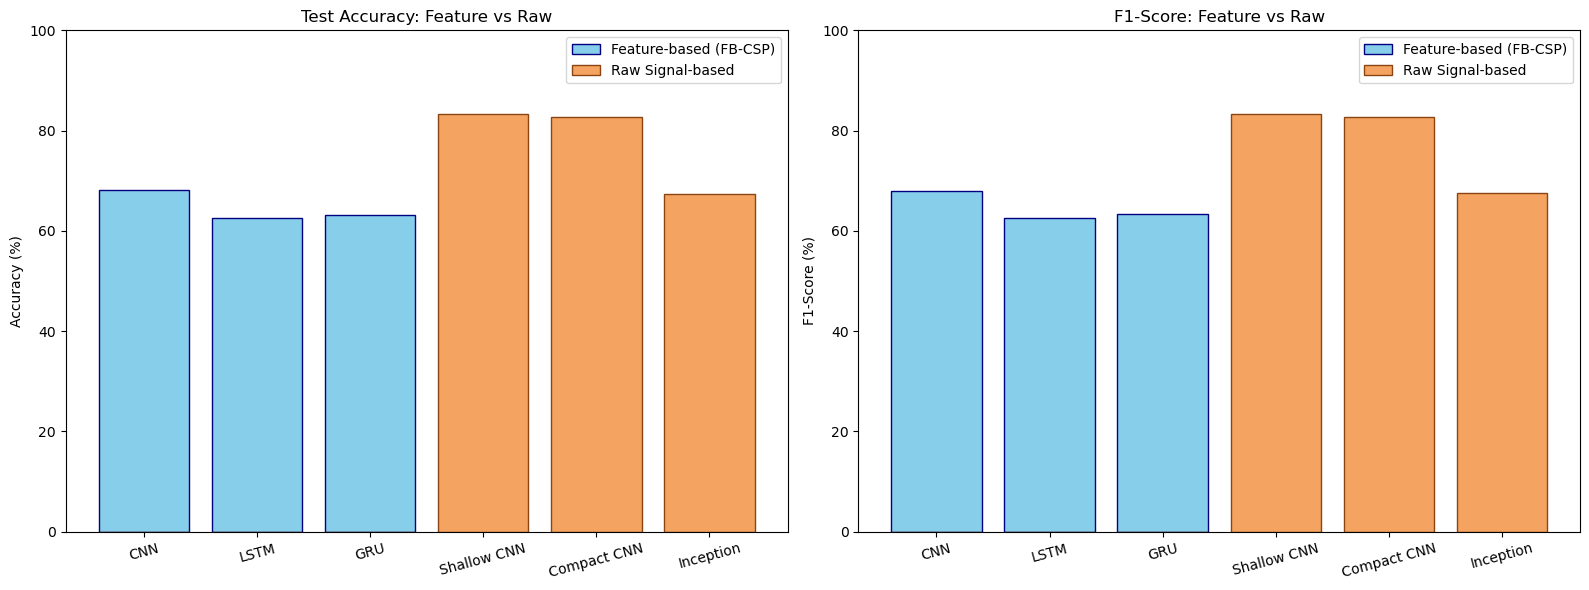

In [29]:
import matplotlib.pyplot as plt
import numpy as np

experiments = ['CNN', 'LSTM', 'GRU', 'Shallow CNN', 'Compact CNN', 'Inception']
y_cnn = cnn.predict(X_test_features_cnn)
y_lstm = lstm.predict(X_test_features_rnn)
y_gru = gru.predict(X_test_features_rnn)
y_shallow = shallow.predict(X_test)
y_compact_cnn = eegnet.predict(X_test)
y_inception = inception.predict(X_test)

y_pred_cnn = np.argmax(y_cnn, axis=1)
y_pred_lstm = np.argmax(y_lstm, axis=1)
y_pred_gru = np.argmax(y_gru, axis=1)
y_pred_shallow = np.argmax(y_shallow, axis=1)
y_pred_compact_cnn = np.argmax(y_compact_cnn, axis=1)
y_pred_inception = np.argmax(y_inception, axis=1)

y_true_labels = np.argmax(y_test, axis=1)   



# --- Calculate Metrics ---
# Group 1: Feature-based (CSP)
feat_metrics_acc = [
    accuracy_score(y_true_labels, y_pred_cnn) * 100,
    accuracy_score(y_true_labels, y_pred_lstm) * 100,
    accuracy_score(y_true_labels, y_pred_gru) * 100,
    0, 0, 0 # Placeholders for the raw slots
]

# Group 2: Raw-based
raw_metrics_acc = [
    0, 0, 0, # Placeholders for the feature slots
    accuracy_score(y_true_labels, y_pred_shallow) * 100,
    accuracy_score(y_true_labels, y_pred_compact_cnn) * 100,
    accuracy_score(y_true_labels, y_pred_inception) * 100,
]

# (Repeat same logic for F1)
feat_metrics_f1 = [
    f1_score(y_true_labels, y_pred_cnn, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_lstm, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_gru, average='weighted') * 100,
    0, 0, 0
]
raw_metrics_f1 = [
    0, 0, 0,
    f1_score(y_true_labels, y_pred_shallow, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_compact_cnn, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_inception, average='weighted') * 100,
]

# --- Plotting ---
x = np.arange(len(experiments))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy Plot
ax1.bar(x, feat_metrics_acc, label='Feature-based (FB-CSP)', color='skyblue', edgecolor='navy')
ax1.bar(x, raw_metrics_acc, label='Raw Signal-based', color='sandybrown', edgecolor='saddlebrown')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Test Accuracy: Feature vs Raw')
ax1.set_xticks(x)
ax1.set_xticklabels(experiments, rotation=15)
ax1.set_ylim(0, 100)
ax1.legend()

# F1 Plot
ax2.bar(x, feat_metrics_f1, color='skyblue',label='Feature-based (FB-CSP)', edgecolor='navy')
ax2.bar(x, raw_metrics_f1, color='sandybrown',label='Raw Signal-based', edgecolor='saddlebrown')
ax2.set_ylabel('F1-Score (%)')
ax2.set_title('F1-Score: Feature vs Raw')
ax2.set_xticks(x)
ax2.set_xticklabels(experiments, rotation=15)
ax2.set_ylim(0, 100)
ax2.legend()

plt.tight_layout()
plt.show()